In [1]:
# Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [4]:
# Loading dataset

In [5]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

In [6]:
df.shape

(15509, 10)

In [7]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [10]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [11]:
# Rating Distribution

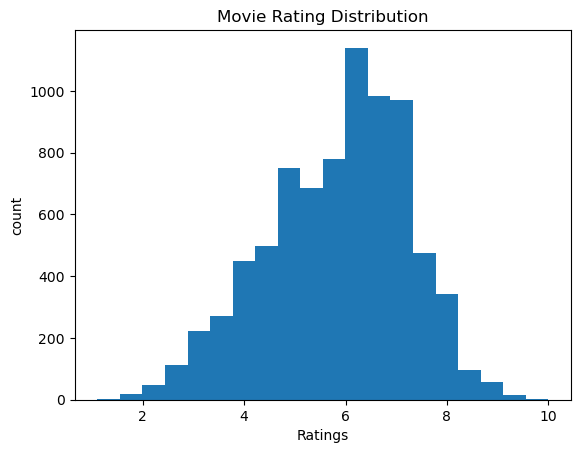

In [12]:
plt.figure()
plt.hist(df["Rating"].dropna(), bins=20)
plt.title("Movie Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("count")
plt.show()

In [13]:
# Data Preprocessing

In [14]:
df = df.dropna(subset=["Rating"]).copy()

In [15]:
# filling missing categorical values

In [16]:
df["Genre"] = df["Genre"].fillna("Unknown")
df["Director"] = df["Director"].fillna("Unknown")
df["Actor 1"] = df["Actor 1"].fillna("Unknown")

In [17]:
# Converting text columns into string

In [18]:
df["Genre"] = df["Genre"].astype(str)
df["Director"] = df["Director"].astype(str)
df["Actor 1"] = df["Actor 1"].astype(str)

In [19]:
# converting Votes column into string

In [20]:
df["Votes"] = df["Votes"].astype(str)

In [21]:
# removing commas from votes

In [22]:
df["Votes"] = df["Votes"].str.replace(",","")

In [23]:
# converting Votes column into numeric values

In [24]:
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")

In [25]:
# filling missing Votes values

In [26]:
df["Votes"] = df["Votes"].fillna(df["Votes"].median())

In [27]:
# converting categorical text into numbers

In [28]:
encoder = LabelEncoder()
df["Genre"] = encoder.fit_transform(df["Genre"])
df["Director"] = encoder.fit_transform(df["Director"])
df["Actor 1"] = encoder.fit_transform(df["Actor 1"])

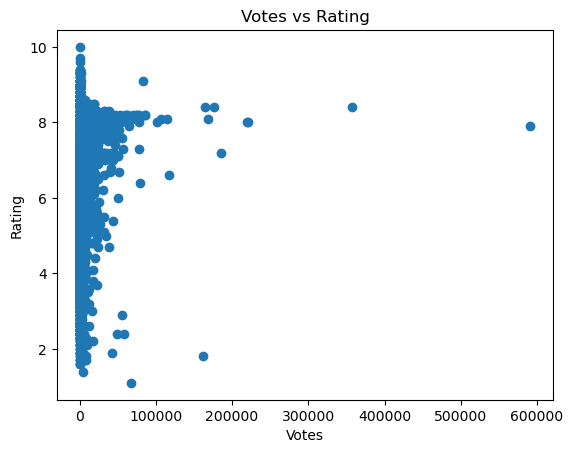

In [29]:

plt.figure()
plt.scatter(df["Votes"], df["Rating"])
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

In [30]:
# Preparing Data

In [31]:
x = df[["Genre", "Director", "Actor 1", "Votes"]]
y = df["Rating"]

#Splitting data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
# Training model

In [33]:
model = RandomForestRegressor( n_estimators=150, random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=150, random_state=42)

In [34]:
prediction = model.predict(x_test)

In [35]:
mae = mean_absolute_error(y_test, prediction)
r2 = r2_score(y_test, prediction)
print("\nMean Absolute Error:", mae)
print("R2 Score:",r2)


Mean Absolute Error: 0.9645998737373737
R2 Score: 0.18821717095678747


In [36]:
# Actual vs Predicted ratings

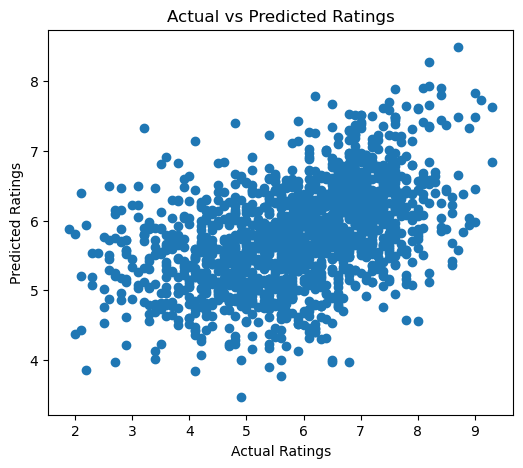

In [37]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, prediction)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()